#Deep Neural Networks
In this notebook, we are going to explore how to implement and tune deep neural networks.

We are going to use Keras to create, train and tune our (deep) models.

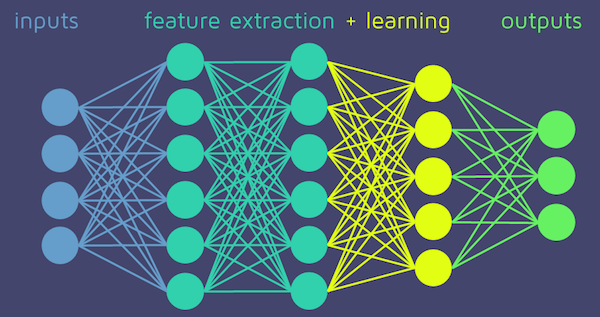

#About the Dataset: Diabetes Health Indicators
The dataset we work with in this lab session is a multiclass problem. The goal is to predict if a person has diabetes (class 2), has prediabetes (class 1) or no diabetes at all (class 0).

The dataset is [hosted on Kaggle](https://www.kaggle.com/alexteboul/diabetes-health-indicators-dataset), containing more than 250,000 rows and 21 features.


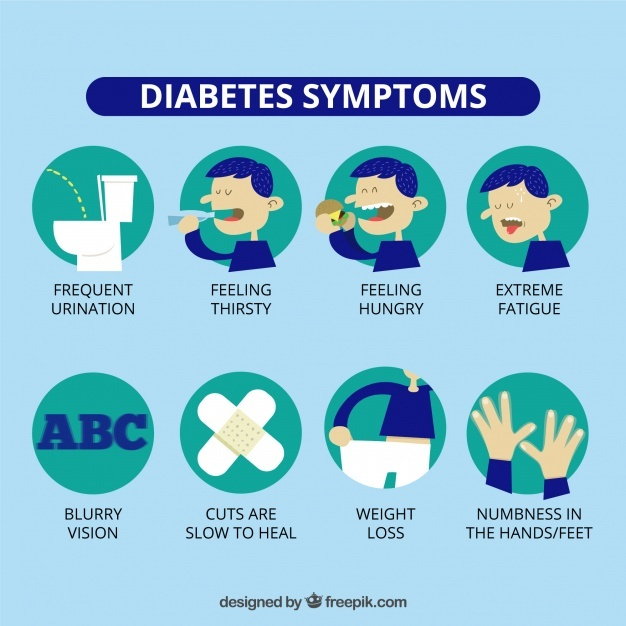

# Installing and Importing Libraries
For the examples we will work on in this notebook, we first need to upgrade the scikit-learn libraries.

Please note that **we will need to restart runtime** after executing the following block.

In [ ]:
# First, let's upgrade scikit-learn package in colab
#!pip uninstall scikit-learn -y
#!pip install -U scikit-learn
import sklearn
#print(sklearn.__version__)

Now let's import the libraries we will need later on.

In [ ]:
import sklearn
import pandas as pd
import io
import os
import numpy as np
import copy
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline
sns.set(color_codes=True)

# Loading the Dataset
Given the size, we load the data directly from Kaggle this time.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"

In [ ]:
! kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset

  0% 0.00/6.03M [00:00<?, ?B/s]
100% 6.03M/6.03M [00:00<00:00, 118MB/s]


In [ ]:
!unzip \*.zip && rm *.zip

Archive:  diabetes-health-indicators-dataset.zip
  inflating: diabetes_012_health_indicators_BRFSS2015.csv  
  inflating: diabetes_binary_5050split_health_indicators_BRFSS2015.csv  
  inflating: diabetes_binary_health_indicators_BRFSS2015.csv  


Next step would be to load the CSV file into a Pandas dataframe.

In [ ]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
print(df.shape)

(253680, 22)


Now let's take a look at the first few rows of the data:

In [ ]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


And here's a summary of the dataset as a whole.
It shows us the columns, their datatype, and how many values in that column are null (empty/missing data). Thankfully, we don't have any missing values!

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Getting Some Insights from Our Data
It is now time to do some EDA! We just play with different data columns to get more sense about our data.

First, let's check the distribution of diabetes types

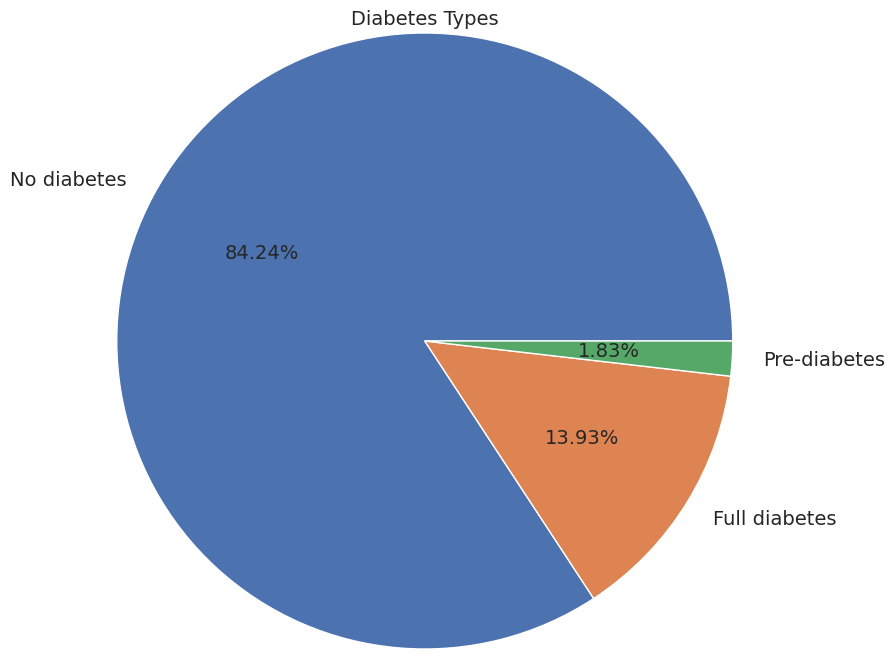

In [ ]:
# Now, let's query the corresponding slice from our main dataframe
selected_labels = ['No diabetes','Full diabetes','Pre-diabetes']
df['Diabetes_012'].value_counts().plot(
    kind = 'pie',figsize=(16,8),autopct='%1.2f%%',ylabel='',radius=1.25,labels=selected_labels,fontsize=14)

# Now let's setup the labels, titles and format y axis as percentages
plt.title("Diabetes Types",fontsize=14)
#plt.legend(selected_labels,loc='lower right',fontsize=14)
plt.show()


We see a significant imbalance in our data, which we should be careful about.

Next, let's see how BMI is dsitributed

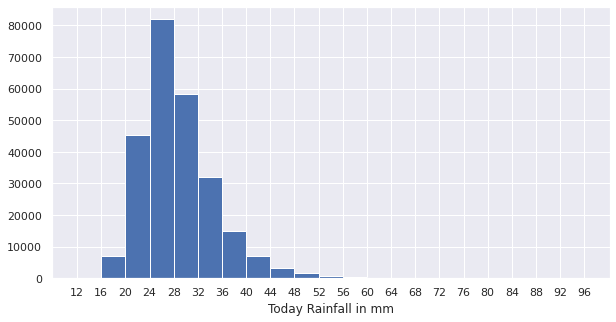

In [ ]:
# Setup bins
no_bins = 20
min_bin_value = int(df['BMI'].min())
max_bin_value = int(df['BMI'].max())+1
no_data_points = df.shape[0]
predefined_bins = list(range(min_bin_value,max_bin_value,int((max_bin_value-min_bin_value)/no_bins)))

# Create the histogram
df['BMI'].hist(bins=predefined_bins,figsize=(10,5))

# Now let's setup the labels, titles and format y axis as percentages
plt.xlabel('BMI Distribution Among Interviewees')
plt.xticks(predefined_bins)
plt.show()

Next, let's see the pairplot of some of the columns and how they correlate with the type of diabetes.

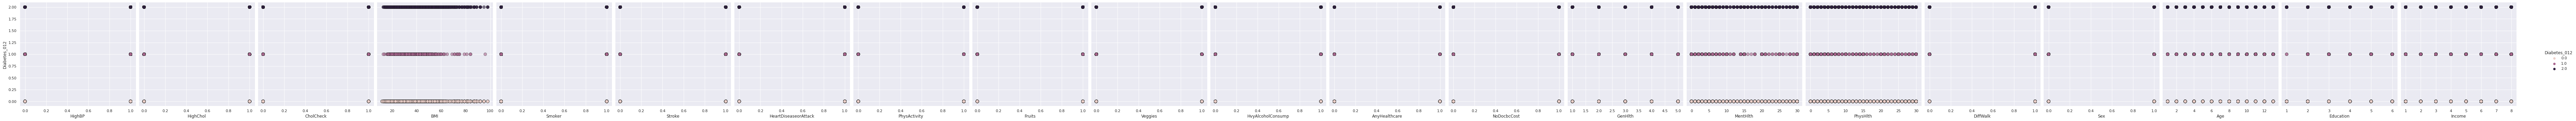

In [ ]:
cols_to_plot = list(df.columns)
cols_to_plot.remove('Diabetes_012')

sns.pairplot(data=df,
                  y_vars=['Diabetes_012'],
                  x_vars=cols_to_plot,
                  hue='Diabetes_012',
                  kind='hist',
                  plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
                  height = 5)

# Data Cleaning
From the above overview, we saw some rows with null values. To save time, we simply drop them here.

In [ ]:
null_columns = []
for col_name in list(df.columns):
  no_null_values = sum(df[col_name].isnull())
  if no_null_values:
    print('Number of null values in column %s is %d' %(col_name,no_null_values))
    null_columns.append(col_name)

The data is very clean. Fantastic!

In [ ]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(253680, 22)

# Feature Engineering
It would be nice to do some feature engineering before moving to the regression phase.

In the interest of time, we forego this step.

# Data Preprocessing
Next step in preparing our data would be to make all columns have numerical values.
Looking at the data, we see that all columns are numerical. Good news for us!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

### Normalization/Stadardization
Our next step would be to "normalize" all the columns so thatthey have a "similar" range. To this end, we will use scikit-learn's SatndardScaler, to make the selected columns have the normal distribution.

In [ ]:
target_variable = df.pop('Diabetes_012')

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = StandardScaler() #MinMaxScaler()

standard_scaling_columns = list(df.columns)
df[standard_scaling_columns] = scaler.fit_transform(df[standard_scaling_columns])
df[standard_scaling_columns].describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,...,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05
mean,-1.250340e-16,5.769939e-17,1.245859e-16,-2.505162e-16,2.688903e-17,-4.033355e-18,4.257430e-18,5.377807e-17,5.601882e-17,-2.487236e-17,...,4.481506e-17,-1.792602e-17,1.711935e-16,8.963011e-18,3.450759e-17,2.554458e-17,1.299637e-16,6.767074e-17,-8.514861e-17,7.170409e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-8.667854e-01,-8.581816e-01,-5.078164e+00,-2.478916e+00,-8.921186e-01,-2.056365e-01,-3.224576e-01,-1.762814e+00,-1.316872e+00,-2.074316e+00,...,-4.407954e+00,-3.031731e-01,-1.414532e+00,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-2.302431e+00,-4.108894e+00,-2.440138e+00
25%,-8.667854e-01,-8.581816e-01,1.969216e-01,-6.631223e-01,-8.921186e-01,-2.056365e-01,-3.224576e-01,5.672748e-01,-1.316872e+00,4.820866e-01,...,2.268626e-01,-3.031731e-01,-4.786188e-01,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-6.653492e-01,-1.065595e+00,-5.088373e-01
50%,-8.667854e-01,-8.581816e-01,1.969216e-01,-2.091739e-01,-8.921186e-01,-2.056365e-01,-3.224576e-01,5.672748e-01,7.593754e-01,4.820866e-01,...,2.268626e-01,-3.031731e-01,-4.786188e-01,-4.296296e-01,-4.865924e-01,-4.497181e-01,-8.870209e-01,-1.051636e-02,-5.116153e-02,4.568129e-01
75%,1.153688e+00,1.165254e+00,1.969216e-01,3.960906e-01,1.120927e+00,-2.056365e-01,-3.224576e-01,5.672748e-01,7.593754e-01,4.820866e-01,...,2.268626e-01,-3.031731e-01,4.572943e-01,-1.598272e-01,-1.424742e-01,-4.497181e-01,1.127369e+00,6.443165e-01,9.632716e-01,9.396380e-01
max,1.153688e+00,1.165254e+00,1.969216e-01,1.053427e+01,1.120927e+00,4.862949e+00,3.101183e+00,5.672748e-01,7.593754e-01,4.820866e-01,...,2.268626e-01,3.298445e+00,2.329121e+00,3.617407e+00,2.954590e+00,2.223615e+00,1.127369e+00,1.626566e+00,9.632716e-01,9.396380e-01


**Important Note**: In practice, it is better to perform normalization *after* we have separated data into train and test, and use only the train set for deriving normalization coefficient. The reason is that we supposedly do not have access to the test data.

# Pareparing Train and Test Sets
Let's break our data into train and test sets to better evaluate the performance of our algorithm.

Here, since we have three classes, we perform one-hot-encoding on the target variable too. We'll then use the softmax activation function (i.e. similar to what we saw on multinomial regression) to perform multiclass classification.

In [ ]:
# First, let's separate the target column, price
from sklearn.preprocessing import OneHotEncoder,LabelBinarizer
enc = LabelBinarizer()
y = enc.fit_transform(target_variable)

In [ ]:
target_variable


0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [ ]:
y

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1]])

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(df,y,test_size=0.3)
print(X_train.shape)
print(X_test.shape)

(177576, 21)
(76104, 21)


# Classification
Now it is time to test classification algorithms in action, starting from linear classifiers.

In [ ]:
# Diable warnings about max_itr not reached etc.!
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

### <font color="green"> Multi-layer Networks with Keras
Next step would be create some networks, probably with more sophisticated architectures, using other available libraries.

We start with a similar multilayer feedforward network, built with Keras.

In [ ]:
# Importing necessary libraries
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import callbacks
import tensorflow as tf
from tensorflow.keras import initializers
from keras.regularizers import l2,l1,l1_l2

In [ ]:
#Early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,          # minimium amount of change to be considered an improvement
    patience=5,              # number of epochs to wait before deciding there is no significant improvement in training
    restore_best_weights=True,
)

### Some Handy Functions
First, let's make a wrapper functions to create models based on given specs. The reason we do this step is to avoid repeating multiple blocks of code.


We start with a function to create a multi-layered feedforward neural network. The way it works is that we specify the following inputs:

*   no_hidden_neurons: this is a list of neurons in the hidden layers. The number of hidden layers is the length of this list.
*   input_size: the number of neurons in the input layer. It is equal to `X_train.shape[1]`
*   activation_func: it is a string specifying the type of the activation function.
*   l1_reg: a real number, which specifies the l1-regualirization coefficient in each layer (the higher it is, the more severe the regularization will be).
*   l2_reg: a real number, which specifies the l2-regualirization coefficient in each layer (the higher it is, the more severe the regularization will be).
*   learning_rate: a real number, specifying the learning rate in the gradient descent algorithm
*   learning_rate_decay: a real number, specifying the decay in the learning rate after a few iterations
*   dropout_rate: the rate at which neurons are "dropped-out" during training. If this value is 0, it means we won't have any dropout
*   weight_initializer: name of the weight initialization technique used to setup the weights when the algorithm starts.
    
Once given these inputs, the function creates the model according to our specs, compile it and return it as the output.

In [ ]:
def create_model(no_hidden_neurons: list=[10], input_size=X_train.shape[1],
                 activation_func: str='relu', l1_reg: float=0.0, l2_reg: float=0.0,
                 learning_rate: float=0.001, learning_rate_decay: float=0.95,
                 dropout_rate: float=0.0,weight_initializer: str='',
                 optimizer_name: str='adam',regularization_type: str='kernel'):

  # Setup the weight initialization techniques
  if weight_initializer == 'RandomNormal':
    weight_initializer = initializers.RandomNormal()
  elif weight_initializer == 'RandomUniform':
    weight_initializer = initializers.RandomUniform()
  elif weight_initializer == 'Zeros':
    weight_initializer = initializers.Zeros()
  elif weight_initializer == 'GlorotUniform':
    weight_initializer = initializers.GlorotUniform()
  elif weight_initializer == 'GlorotNormal':
    weight_initializer = initializers.GlorotNormal()
  else:
    weight_initializer = None

  model = Sequential()

  model.add(Input(shape=input_size))
  # Add hidden layers
  itr = 0
  for n_l in no_hidden_neurons:
      # Add regularization
      if l1_reg and l2_reg:
        if regularization_type == 'activation':
          model.add(Dense(n_l, activation=activation_func,activity_regularizer=l1_l2(l1=l1_reg,l2=l2_reg),kernel_initializer=weight_initializer))
        else:
          model.add(Dense(n_l, activation=activation_func,kernel_regularizer=l1_l2(l1=l1_reg,l2=l2_reg),kernel_initializer=weight_initializer))
      elif l1_reg:
        if regularization_type == 'activation':
          model.add(Dense(n_l, activation=activation_func,activity_regularizer=l1(l1_reg),kernel_initializer=weight_initializer))
        else:
          model.add(Dense(n_l, activation=activation_func,kernel_regularizer=l1(l1_reg),kernel_initializer=weight_initializer))
      elif l2_reg:
        if regularization_type == 'activation':
          model.add(Dense(n_l, activation=activation_func,activity_regularizer=l2(l2_reg),kernel_initializer=weight_initializer))
        else:
          model.add(Dense(n_l, activation=activation_func,kernel_regularizer=l2(l2_reg),kernel_initializer=weight_initializer))
      else:
        model.add(Dense(n_l, activation=activation_func,kernel_initializer=weight_initializer))

      if dropout_rate and itr%2 == 0:
        model.add(Dropout(dropout_rate))

      itr += 1

  # Add the last layer's activation layer
  model.add(Dense(3, activation='softmax'))

  # Next, let's compile it
  if optimizer_name == 'sgd':
    opimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  elif optimizer_name == 'RMSprop':
    opimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
  elif optimizer_name == 'Adadelta':
    opimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate,rho=learning_rate_decay)
  else:
    opimizer = tf.keras.optimizers.Adam(lr=learning_rate,beta_1=learning_rate_decay)
  model.compile(
        loss='categorical_crossentropy',
        optimizer=opimizer,
        metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
        )

  return model

The next function is used to plot the loss or accuracy (precision/recall) of the model during training. The inputs are:


*   history: this is the output history of the keras fit() method
*   plot_type: if it is "loss", the training/validation loss will be plotted. Otherwise, the accuracy graph is returned.



In [ ]:
def plot_history(history,plot_type: str='loss'):
  hist_df = pd.DataFrame(history.history)
  plt.figure(figsize=(20,8))
  colors = []
  columns_to_plot = []
  labels = []
  for col_name in hist_df.columns:

    # Define colors
    if 'val' in col_name:
      validation = True
      color_base = 'r'
      label_base = 'Validation'
    else:
      validation = False
      color_base = 'b'
      label_base = 'Training'

    if plot_type == 'loss':
      if 'loss' in col_name:
        labels.append(label_base)
        columns_to_plot.append(col_name)
        colors.append(color_base)
    else:
      if 'loss' in col_name:
        continue
      if 'recall' in col_name:
        color = color_base + '--'
        label = label_base + 'Recall'
      else:
        color = color_base
        label = label_base + 'Precision'

      labels.append(label)
      columns_to_plot.append(col_name)
      colors.append(color)



  for itr in range(0,len(columns_to_plot)):
    plt.plot(hist_df.loc[:, [columns_to_plot[itr]]], colors[itr], label=labels[itr],lw=4)

  plt.ylabel(plot_type)
  plt.xlabel('Epochs')
  plt.legend(loc="best")

  plt.show()

### Simple Neural Network with no Regularization
Now that we have all the ingredients, let's try them out in practice by creating a simple network with

*   3 hidden layers of sizes 50,25,10 hidden neurons
*   "sigmoid" activation function
*   no regularization



In [ ]:
model = create_model(no_hidden_neurons=[50,25,10], activation_func='sigmoid',l1_reg=0,l2_reg=0)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                1100      
                                                                 
 dense_1 (Dense)             (None, 25)                1275      
                                                                 
 dense_2 (Dense)             (None, 10)                260       
                                                                 
 dense_3 (Dense)             (None, 3)                 33        
                                                                 
Total params: 2668 (10.42 KB)
Trainable params: 2668 (10.42 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Now, let's perform the training:

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 15,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/15
8879/8879 [==============================] - 31s 3ms/step - loss: 0.4305 - precision: 0.8463 - recall: 0.8253 - val_loss: 0.3941 - val_precision: 0.8557 - val_recall: 0.8407
Epoch 2/15
8879/8879 [==============================] - 30s 3ms/step - loss: 0.3970 - precision: 0.8562 - recall: 0.8389 - val_loss: 0.3918 - val_precision: 0.8562 - val_recall: 0.8416
Epoch 3/15
8879/8879 [==============================] - 39s 4ms/step - loss: 0.3956 - precision: 0.8558 - recall: 0.8409 - val_loss: 0.3924 - val_precision: 0.8550 - val_recall: 0.8431
Epoch 4/15
8879/8879 [==============================] - 29s 3ms/step - loss: 0.3953 - precision: 0.8557 - recall: 0.8419 - val_loss: 0.3899 - val_precision: 0.8550 - val_recall: 0.8441
Epoch 5/15
8879/8879 [==============================] - 27s 3ms/step - loss: 0.3946 - precision: 0.8553 - recall: 0.8428 - val_loss: 0.3911 - val_precision: 0.8545 - val_recall: 0.8409
Epoch 6/15
8879/8879 [==============================] - 26s 3ms/step - loss

In [ ]:
predictions = model.predict(X_test)

2379/2379 [==============================] - 5s 2ms/step


In [ ]:
def convert_predictions(predictions):
  output = np.argmax(predictions,axis=1)
  return output

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
print('Weighted F1-score is %.2f' %f1_score(convert_predictions(y_test), convert_predictions(predictions), average='weighted'))

Weighted F1-score is 0.81


Let's see the progress of our algorithm in each iteration:

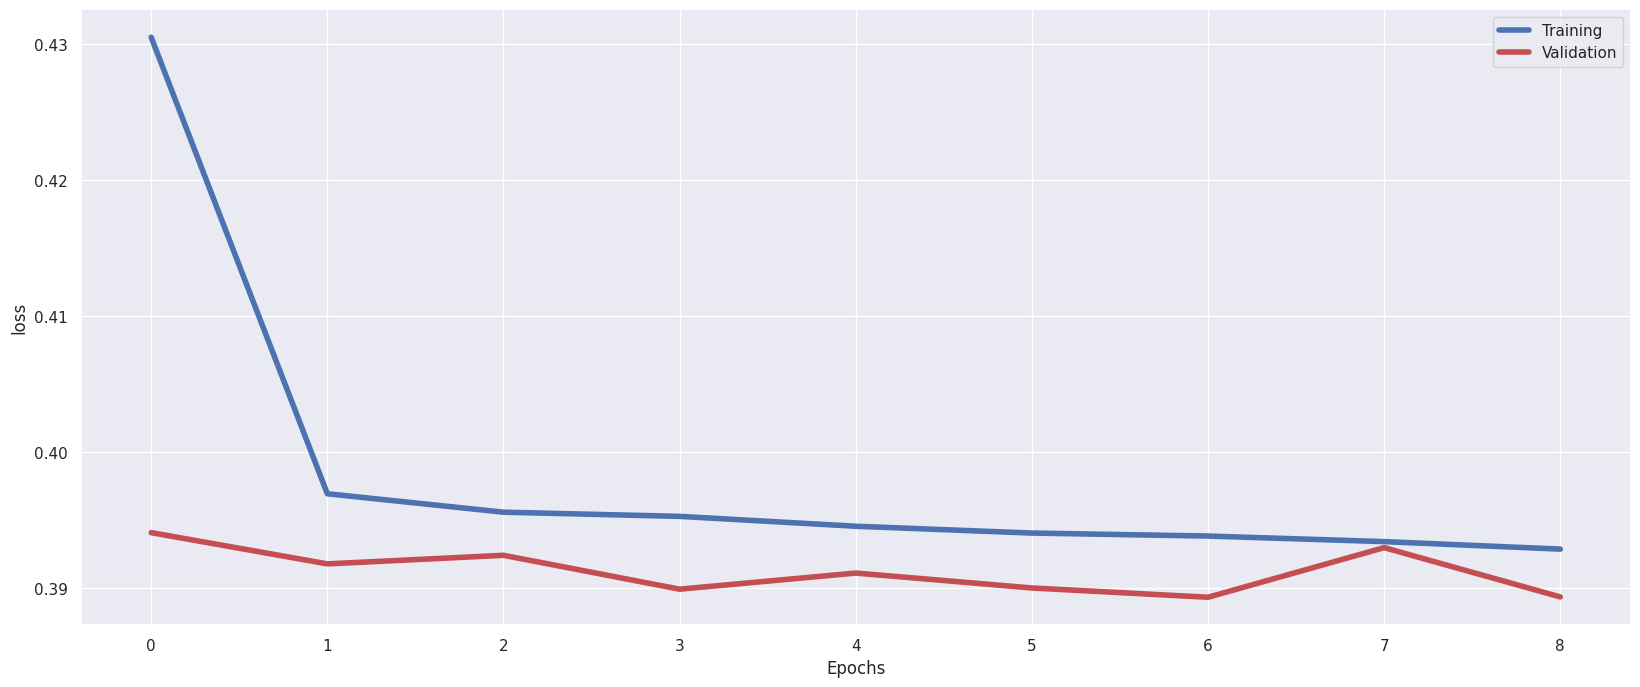

In [ ]:
plot_history(history,plot_type='loss')

### Based on the above graph, should we have continued the training process?
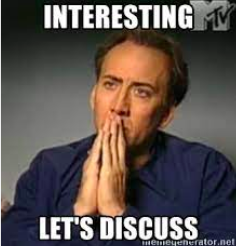






Finally, let's see the confusion matrix to see how we are performing with respect to each class.

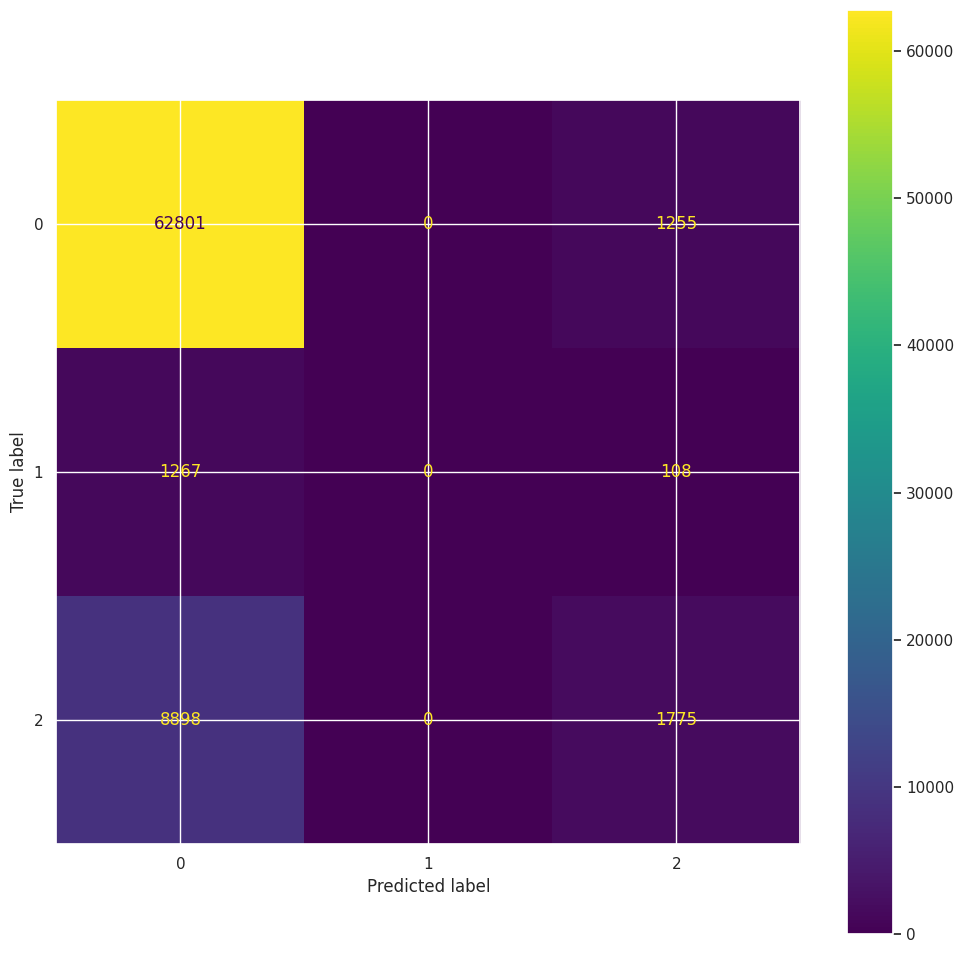

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(convert_predictions(y_test), convert_predictions(predictions),ax=ax)
plt.show()

Appranetly, the algorithm is not doing so well in identifying patients with diabetes. This means we need to tune the algorithm more.

### <font color="blue">K-Fold Cross Validation
So far, we have seen the performance of the algorithm over the test set. But depending on the split, we might get lucky/unlucky and overestimate/underestimate the accuracy.

To resolve this issue, we will do k-fold cross validation, to be more sure about the performance of our algorithm.


In [ ]:
from sklearn.model_selection import KFold#, StratifiedKFold

To make things easier and allowing code recycling, we create a similar wrapper-function for k-fold cross validation and use it throughout this notebook. The inputs are:


*   no_folds: the number of folds we are going to use
*   plot_results: if True, the progress of training procedure is displayed and the resulting loss/accuracy is going to be dispayed after each fold is done.
*   models_params: this is the dictionry of the parameters we need to pass to the create_model() function above
*   training_params: these are the parameters used to tune the training algorithm

Once the inputs are specified, the function loops over the specified number of folds, and return the average and standard deviation of the accuracy over the validation set.



In [ ]:
def kfold_validation(no_folds: int=3, plot_results: bool=True,
                     model_params: dict={},training_params: dict={}):
  validation_set_accuracy = []
  models = []

  if plot_results:
    verbose=2
  else:
    verbose=0

  itr = 0
  kf = KFold(n_splits=no_folds)
  for train_index, val_index in kf.split(X_train,y_train):
    train_set, y_train_set = X_train.iloc[train_index], y_train[train_index]
    val_set,y_val = X_train.iloc[val_index], y_train[val_index]

    # First, create a new model
    model = create_model(**model_params)
    #model.summary()

    # Finally, let's fit the model
    history = model.fit(train_set, y_train_set,
                      validation_data=(val_set,y_val),
                      callbacks=[early_stopping],
                      verbose=verbose,
                      **training_params,
                      )


    # Finally, let's
    pred_val = model.predict(val_set)
    f1 = f1_score(convert_predictions(y_val), convert_predictions(pred_val), average='weighted')

    validation_set_accuracy.append(f1)
    models.append(model)

    # Plot the results
    if plot_results:
      plot_history(history,plot_type='acc')


  # Convert to numpy array
  validation_set_accuracy = np.array(validation_set_accuracy)

  # Return the best model (as an example)
  best_model = models[np.argmax(validation_set_accuracy)]

  # Print the reults
  if plot_results:
    print('Average F1-Score over validation set is %.2f' %validation_set_accuracy.mean())
    print('STD of F1-Score over validation set is %.2f' %validation_set_accuracy.std())
  return best_model,validation_set_accuracy.mean(),validation_set_accuracy.std()

In [ ]:
kfold_params = {
    'no_folds': 3,
    'plot_results': False,
    'model_params': {
      'no_hidden_neurons': [25,10],
      'activation_func': 'sigmoid',
      'l1_reg': 0,
      'l2_reg': 0,
      'learning_rate': 0.001,
      'learning_rate_decay': 0.99,
      'dropout_rate':0,
      'weight_initializer': None,
      'optimizer_name': 'adam',
      'regularization_type': 'kernel',
  },
  'training_params': {
    'batch_size': 16,
    'epochs': 25
  }
}

In [ ]:
model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

1850/1850 [==============================] - 3s 2ms/step


1850/1850 [==============================] - 4s 2ms/step


1850/1850 [==============================] - 4s 2ms/step


In [ ]:
kfold_params['plot_results'] = False

### <font color="blue">Effect of Learning Rate
Now that we have tested the performance of the algorithm more thoroughly using k-fold cross validation, let's explore the effect of other parameters, starting with the learning rate.

### Can you recall what learning rate was and how it affects the results?
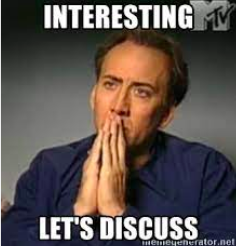






But before doing that, and in the interest of having as many reusable code as possible, let's create another function which gets a variable name and a list values, then

1.   Goes over items of the list one by one
2.   Performs k-fold cross validation
3.   Stores the provided accuracy for the validation and test sets
4.   Plot the results and returns the best value as well as the best model as the output.


In [ ]:
def evaluate_efect_param(parameter_type: str='kfold', parameter_name: str='', values_list: list=[]):
  scores_val = []
  scores_test = []
  models = []
  for val in values_list:

      if parameter_type == 'kfold':
        kfold_params[parameter_name] = val
      elif parameter_type == 'model_params':
        kfold_params['model_params'][parameter_name] = val
      elif parameter_type == 'training_params':
        kfold_params['training_params'][parameter_name] = val

      model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

      scores_val.append(validation_set_accuracy_mean)

      predictions = model.predict(X_test)
      score_test = f1_score(convert_predictions(y_test), convert_predictions(predictions), average='weighted')
      scores_test.append(score_test)

      models.append(model)
      print('Val: %s, Validation Score: %.3f, Test Score: %.3f' %(str(val),validation_set_accuracy_mean,score_test))


  # Plot the results
  plt.figure(figsize=(20,8))
  str_values_list = []
  for v in values_list:
    str_values_list.append(str(v))

  plt.plot(str_values_list,scores_test,lw=5)
  plt.plot(str_values_list,scores_val,lw=5,color='orange')
  plt.xlabel(parameter_name)
  plt.ylabel('F1-Score')
  plt.legend(['F1: Test Set','F1: Validation Set'])
  plt.show()

  # Get the best model
  best_model = models[np.argmax(scores_val)]
  best_val = values_list[np.argmax(scores_val)]

  return best_model,best_val


So let's test this function by exploring the effects of learning rate on training.

Val: 0.0001, Validation Score: 0.805, Test Score: 0.808
Val: 0.001, Validation Score: 0.811, Test Score: 0.816
Val: 0.01, Validation Score: 0.811, Test Score: 0.819
Val: 0.05, Validation Score: 0.770, Test Score: 0.772


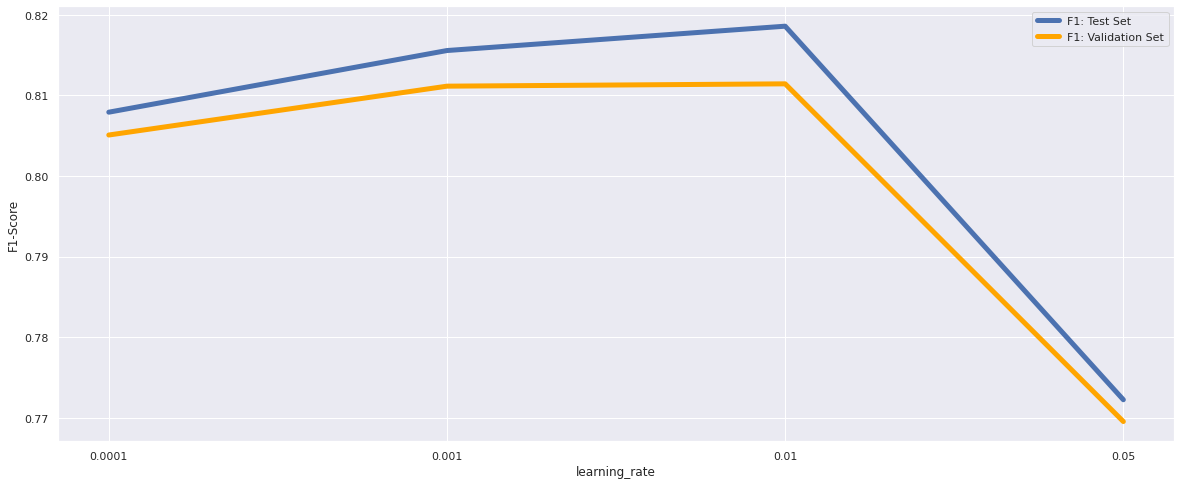

In [ ]:
model,best_lr = evaluate_efect_param(parameter_type='model_params',parameter_name='learning_rate', values_list=[0.0001,0.001,.01,0.05])

The above result shows that a very low or a very high learning rate results in a not-so-good result, as we expected.

#### Effect of Learning Rate Decay
Another factor that could affect the speed of learning, as well as convergence, is the rate at which learning rate is decayed, i.e. after a few iterations, the algorithm can reduce learning rate in the hope not to miss the (local) minimum.

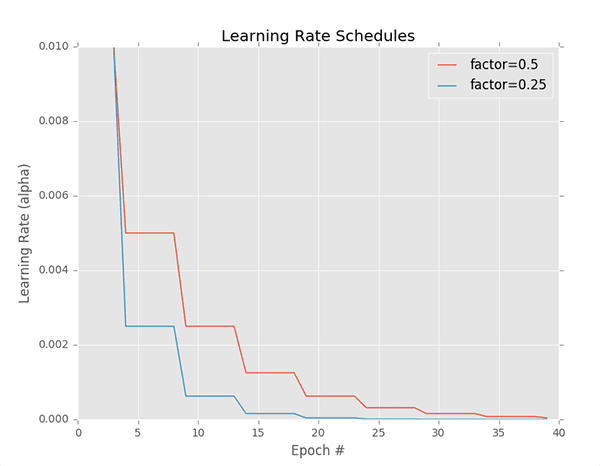

### Why shall we reduce learning at all?!
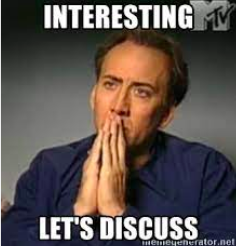






Val: 0.75, Validation Score: 0.806, Test Score: 0.817
Val: 0.85, Validation Score: 0.809, Test Score: 0.812
Val: 0.95, Validation Score: 0.806, Test Score: 0.811


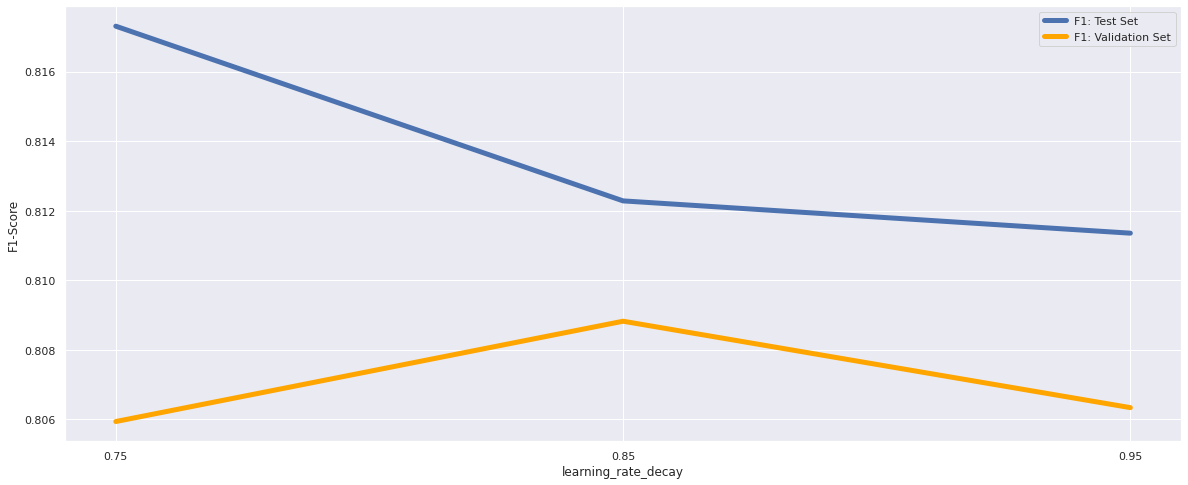

In [ ]:
kfold_params['model_params']['learning_rate'] = best_lr
model,best_lr_decay = evaluate_efect_param(parameter_type='model_params',parameter_name='learning_rate_decay', values_list=[0.75,0.85,0.95])

When the decay is too high (the rate is low), we get worse results, because the learning rate drops too fast, which means the learning will be slow and the algorithm underperforms.

On the other hand, if there is no decay or decay is very low, the algorithm might pass the optimum point and we get a worse result again. So this is something we need to tune as well.

### <font color="blue">Effect of Batch Size
Next, we can check the effect of batch size, fixing the learning rate and decay to their best values we had found so far.

Val: 4, Validation Score: 0.807, Test Score: 0.814
Val: 16, Validation Score: 0.808, Test Score: 0.810
Val: 32, Validation Score: 0.811, Test Score: 0.813
Val: 64, Validation Score: 0.806, Test Score: 0.822
Val: 256, Validation Score: 0.813, Test Score: 0.816
Val: 1024, Validation Score: 0.808, Test Score: 0.811


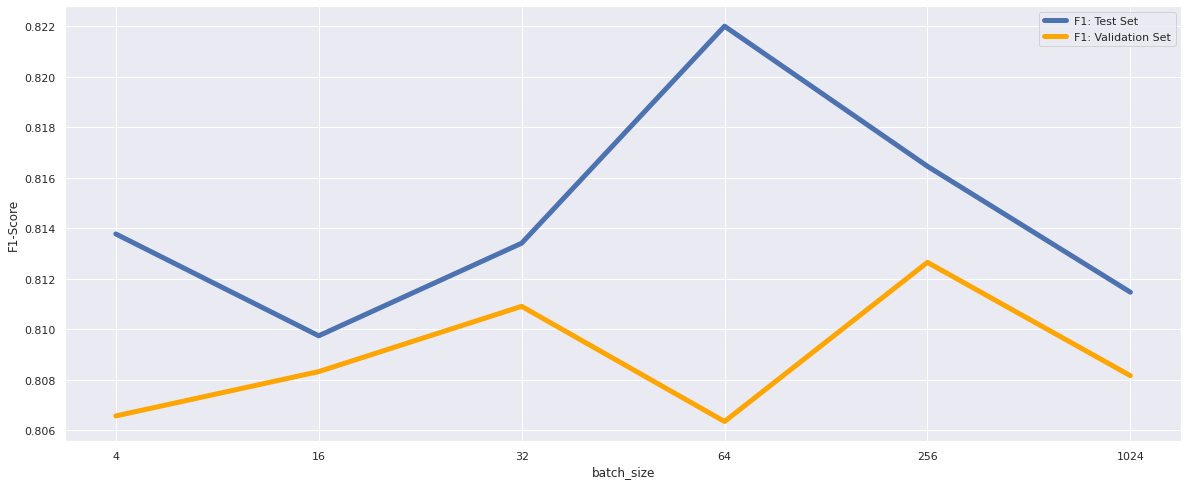

In [ ]:
kfold_params['model_params']['learning_rate_decay'] = best_lr_decay
model,best_batch_size = evaluate_efect_param(parameter_type='training_params',parameter_name='batch_size', values_list=[4,16,32,64,256,1024])

We see a similar trend with batch size.

### <font color="blue">Weight Initialization Techniques
In the lecture, we saw that the way wieghts are initialized has a crucial impact on the training process, especially when "sigmoid" or "tanh" activation functions are used.

So let's explore some of the options we have and check their effect on the performance of the algorithm. For a complete list of weight initialization methods available in Keras, check [this link](https://keras.io/api/layers/initializers/).

Val: RandomNormal, Validation Score: 0.814, Test Score: 0.819
Val: RandomUniform, Validation Score: 0.812, Test Score: 0.819
Val: Zeros, Validation Score: 0.811, Test Score: 0.814
Val: GlorotUniform, Validation Score: 0.810, Test Score: 0.815
Val: GlorotNormal, Validation Score: 0.814, Test Score: 0.819


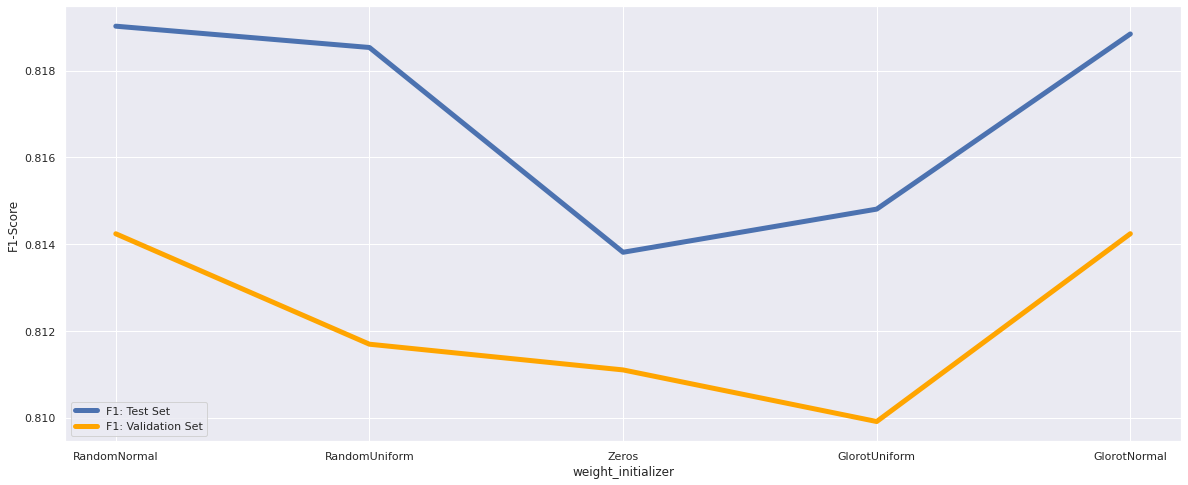

In [ ]:
weight_initializers=['RandomNormal','RandomUniform','Zeros','GlorotUniform','GlorotNormal']
kfold_params['training_params']['batch_size'] = best_batch_size
model,best_weight_initializer = evaluate_efect_param(parameter_type='model_params',parameter_name='weight_initializer', values_list=weight_initializers)

It looks like the RandomUnifor approach and "Xavier" initialization heuristic (known as GlorotUniform in Keras) works better than the other options. As a reminder, it intializes the weights from layer l to layer l+1 according to:

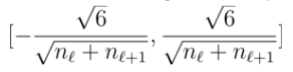

In [ ]:
kfold_params['model_params']['weight_initializer'] = best_weight_initializer

### <font color="blue">Importance of Activation Functions
With the weights setup, we can also experiment with the activation functions. Some of the functions we have seen in the class. Some others are provided below as well.

For a complete list of activation functions available in Keras, please check [this link](https://keras.io/api/layers/activations/).

### Before we continue, why activation function plays an important role in training deep networks?
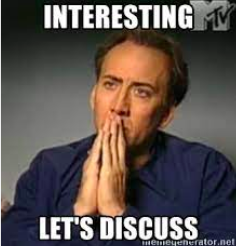






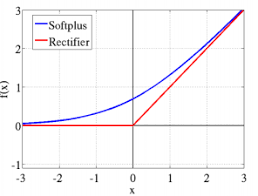

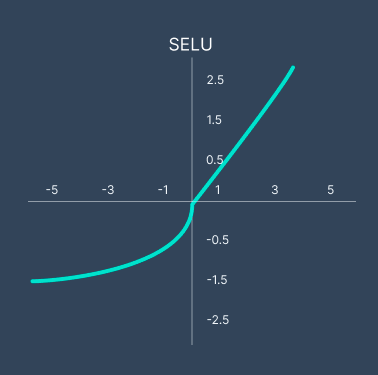

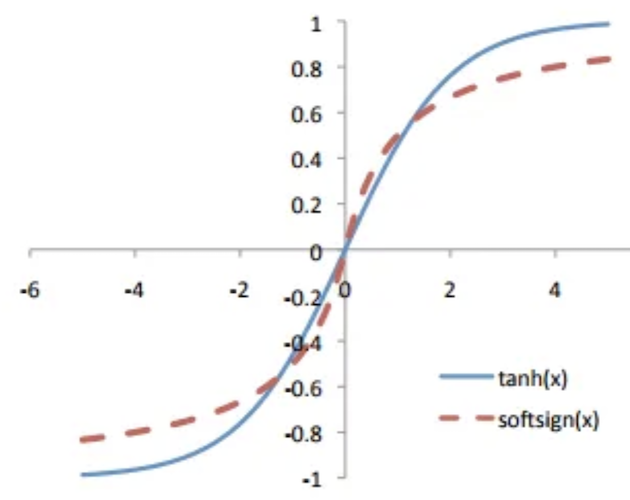

Val: relu, Validation Score: 0.812, Test Score: 0.818
Val: tanh, Validation Score: 0.808, Test Score: 0.818
Val: sigmoid, Validation Score: 0.811, Test Score: 0.816
Val: softplus, Validation Score: 0.806, Test Score: 0.812
Val: softsign, Validation Score: 0.810, Test Score: 0.817
Val: selu, Validation Score: 0.808, Test Score: 0.818


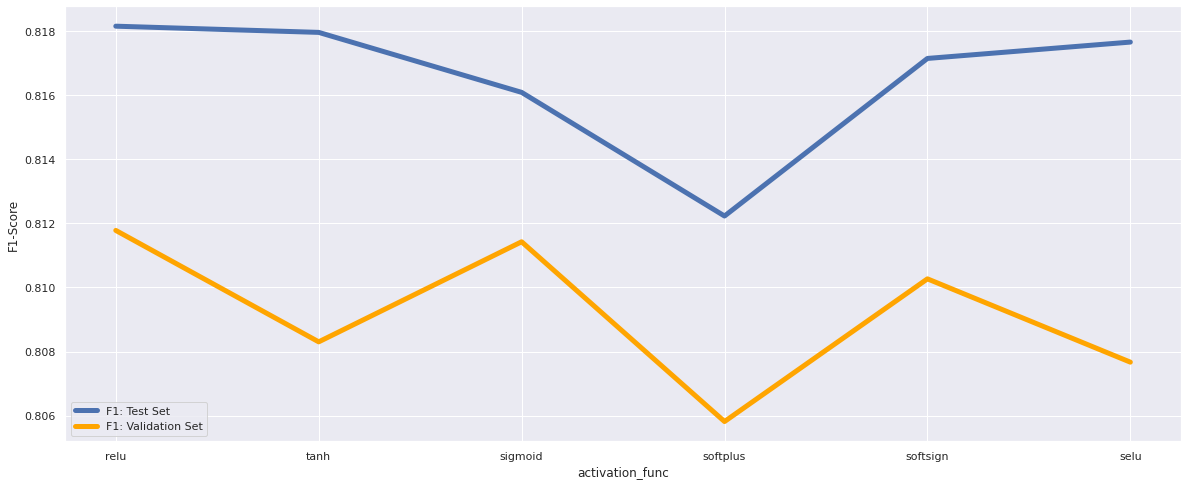

In [ ]:
model,best_activation_func = evaluate_efect_param(parameter_type='model_params',parameter_name='activation_func', values_list=['relu','tanh','sigmoid','softplus','softsign','selu'])
kfold_params['model_params']['activation_func'] = best_activation_func

Based on the results above, it looks like softplus and sigmoid (with the best initialization technique above) outperform other approaches.

### <font color="blue">Effect of L1 and L2 Regularization
We saw in earlier sessions that regularization has an important role in preventing overfitting. Therefore, it would be interesting to see how they affect the performance of our neural network.

There are three main types of reguliarizers [available in Keras](https://keras.io/api/layers/regularizers/) layers:


*   kernel_regularizer: applies regularization penalty to the weights
*   activity_regularizer: regularizes the *output* neurons of a layer, in order to keep their value bounded (similar to normalizing te output)
*   bias_regularizer: applies regularization to the bias (i.e. the contant threshold) in neurons. The higher bias_regularizer is, the closer the bias would be to zero.



Here, we play with L1 and L2 regularization coefficients.

Val: 1e-05, Validation Score: 0.811, Test Score: 0.817
Val: 0.0001, Validation Score: 0.811, Test Score: 0.815
Val: 0.001, Validation Score: 0.804, Test Score: 0.813
Val: 0.01, Validation Score: 0.801, Test Score: 0.807


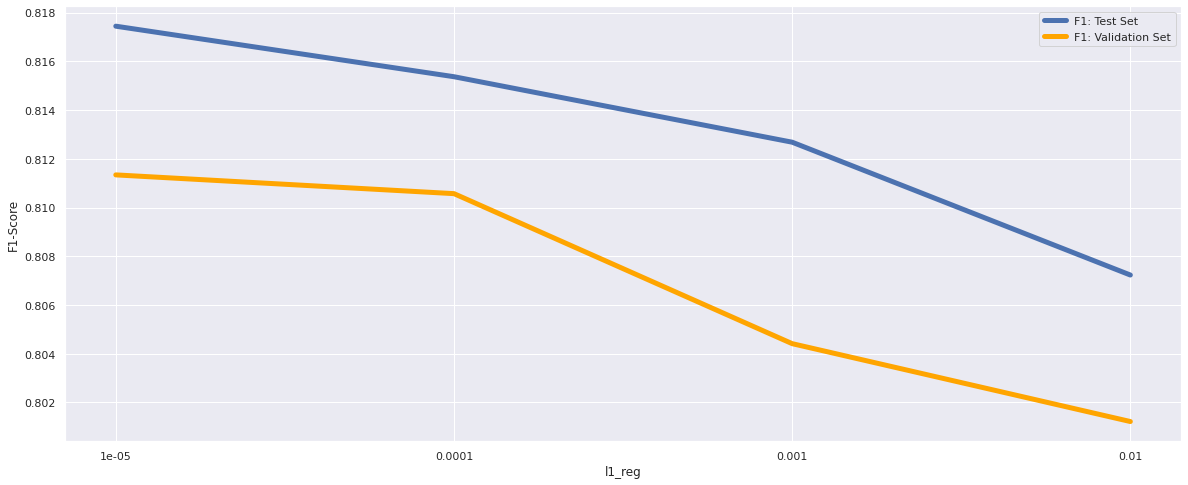

In [ ]:
model,best_l1_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l1_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l1_reg'] = best_l1_reg

It looks like regularization has an adevrasry effect on performance in our example network, maybe because the values we have chosen is quite high.


Likewise, we can test effects of L2-regularization:

Val: 1e-05, Validation Score: 0.809, Test Score: 0.816
Val: 0.0001, Validation Score: 0.809, Test Score: 0.813
Val: 0.001, Validation Score: 0.807, Test Score: 0.814
Val: 0.01, Validation Score: 0.800, Test Score: 0.806


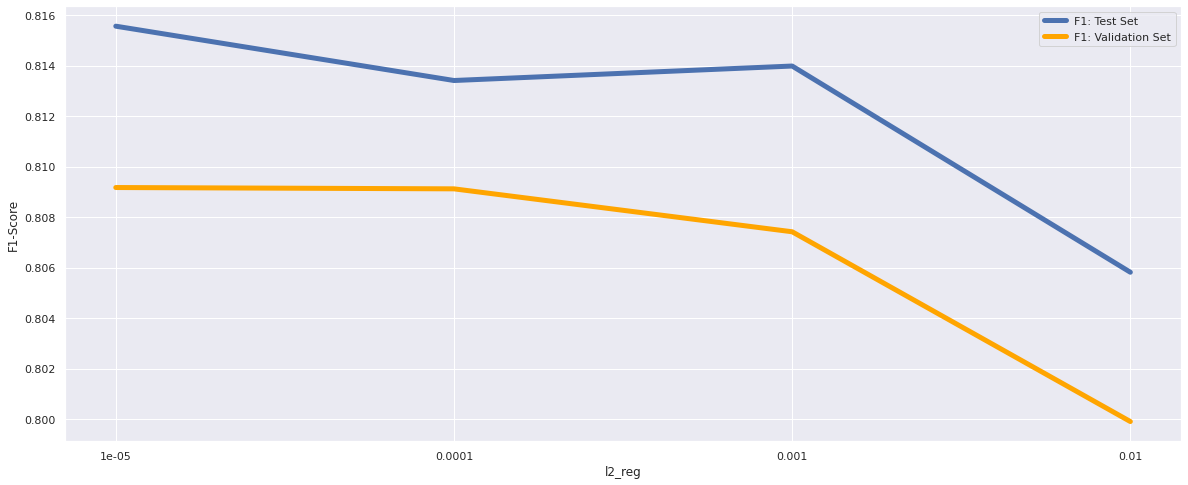

In [ ]:
model,best_l2_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l2_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l2_reg'] = best_l2_reg

Let's also check the effect of regularization on the activation functions

Val: 1e-05, Validation Score: 0.809, Test Score: 0.814
Val: 0.0001, Validation Score: 0.811, Test Score: 0.819
Val: 0.001, Validation Score: 0.806, Test Score: 0.808
Val: 0.01, Validation Score: 0.804, Test Score: 0.809


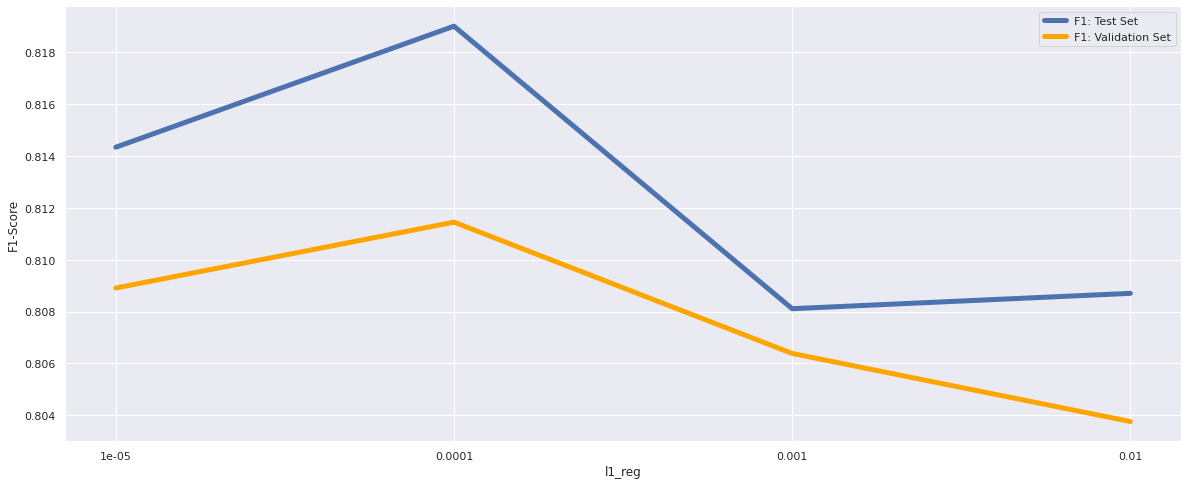

In [ ]:
kfold_params['model_params']['regularization_type'] = 'activation'
model,best_l1_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l1_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l1_reg'] = best_l1_reg

Val: 1e-05, Validation Score: 0.807, Test Score: 0.813
Val: 0.0001, Validation Score: 0.807, Test Score: 0.817
Val: 0.001, Validation Score: 0.801, Test Score: 0.813
Val: 0.01, Validation Score: 0.804, Test Score: 0.810


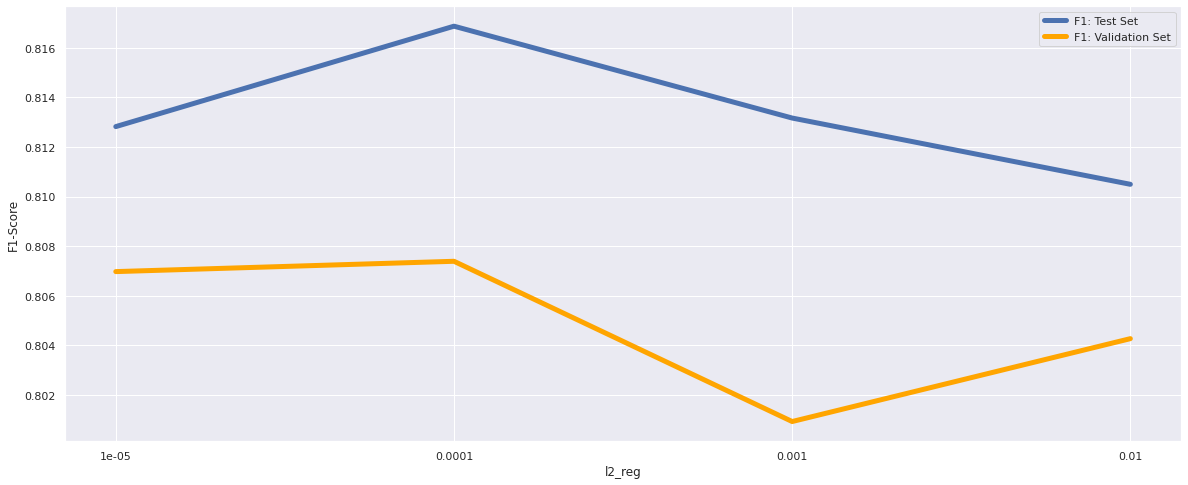

In [ ]:
model,best_l2_reg = evaluate_efect_param(parameter_type='model_params',parameter_name='l2_reg', values_list=[0.00001,0.0001,0.001,0.01])
kfold_params['model_params']['l2_reg'] = best_l2_reg

### <font color="blue">Effect of Dropout
Dropout is the process of ignoring some neuron randomly during each training epoch. In principle, it should add robustness to our algorithm, as it forces neurons to learn features that are not just specific to the training set. Let's see how they work in practice.


Val: 0.0001, Validation Score: 0.806, Test Score: 0.809
Val: 0.01, Validation Score: 0.808, Test Score: 0.816
Val: 0.1, Validation Score: 0.805, Test Score: 0.815
Val: 0.3, Validation Score: 0.791, Test Score: 0.801


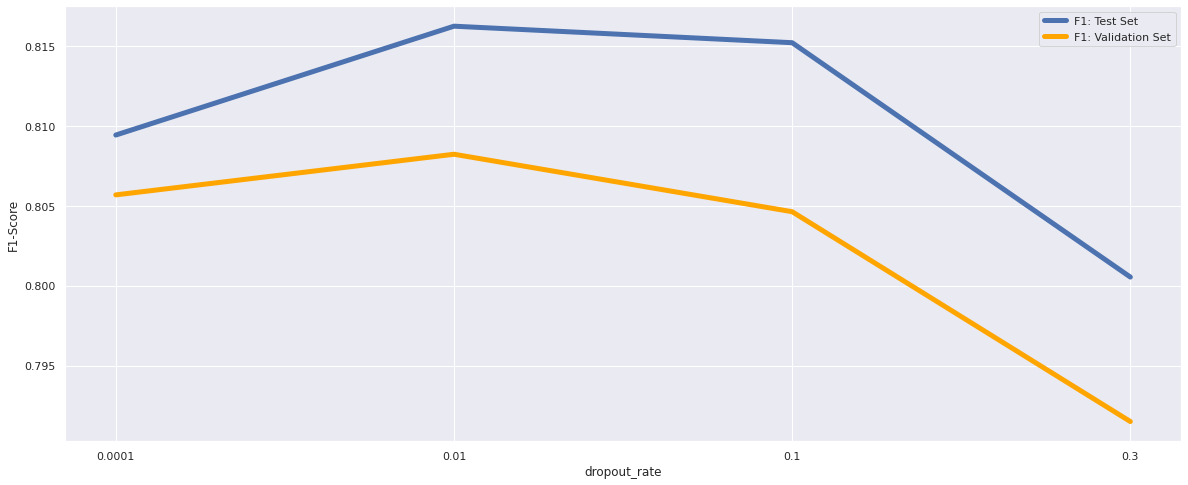

In [ ]:
model,best_dropout_rate = evaluate_efect_param(parameter_type='model_params',parameter_name='dropout_rate', values_list=[0.0001,0.01,0.1,0.3])
kfold_params['model_params']['dropout_rate'] = best_dropout_rate

### <font color="blue">Effect of Number of Layers and Network Size
So far, we have kept the structure of network intact. What if we add more layers, with different number of neurons? will that affect the performance?


### Do you expect a larger network result in a better performance or the opposite?
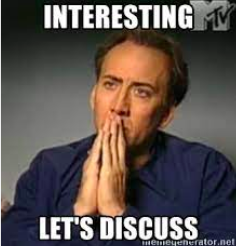






Val: [10], Validation Score: 0.806, Test Score: 0.810
Val: [30, 10], Validation Score: 0.807, Test Score: 0.814
Val: [20, 10, 6], Validation Score: 0.806, Test Score: 0.813


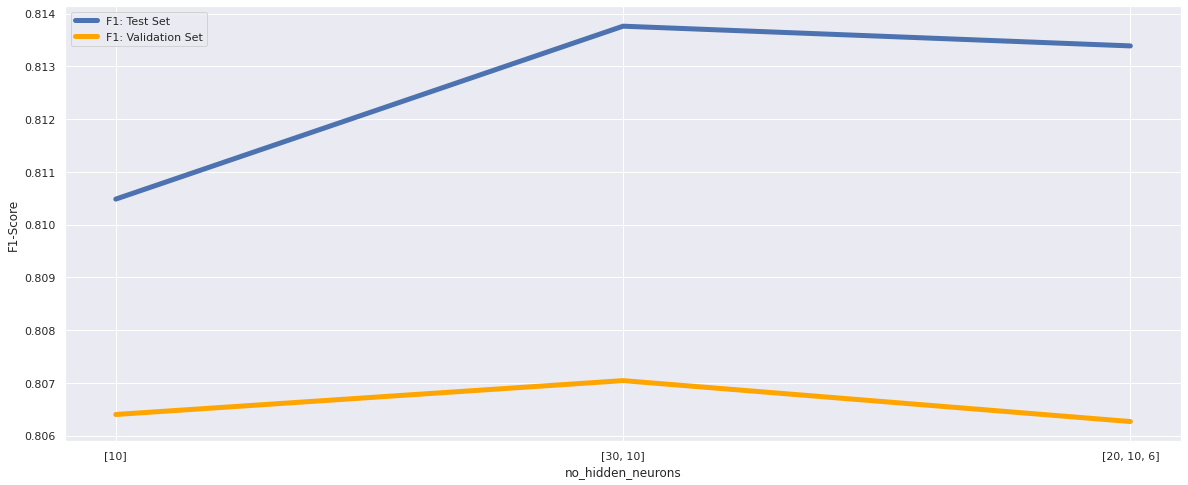

In [ ]:
model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='no_hidden_neurons',values_list=[[10],[30,10],[20,10,6]])
kfold_params['model_params']['no_hidden_neurons'] = best_architecture

It seems that adding more neurons is of no use. Maybe it is because we have kept the number of epochs fixed, and to a minimum. Larger networks may need more epochs to converge.

### <font color="blue">Effect of Number of Epochs
We can also test the effect of training for many epochs and see at what number of epochs we get the best results.


Val: 10, Validation Score: 0.812, Test Score: 0.817
Val: 30, Validation Score: 0.806, Test Score: 0.809
Val: 50, Validation Score: 0.806, Test Score: 0.809


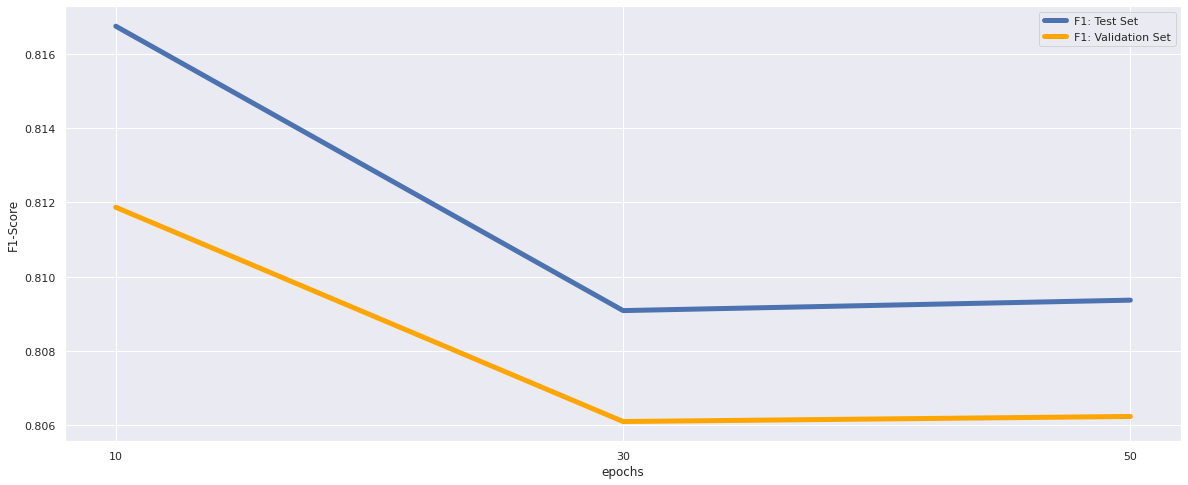

In [ ]:
model,best_no_epochs = evaluate_efect_param(parameter_type='training_params',parameter_name='epochs', values_list=[10,30,50])
kfold_params['training_params']['epochs'] = best_no_epochs

It seems that the number of epochs does not have much influence on the performance on the test set, so we stick with our small number as before.

In [ ]:
kfold_params['training_params']['epochs'] = 3

### <font color="blue">Effect of Optimizer
There are multiple opitmizers we can use in the training algorithm. For a complete list, please check [this link](https://keras.io/api/optimizers/).


The following image may help getting more intuition about the effect of optimizer.

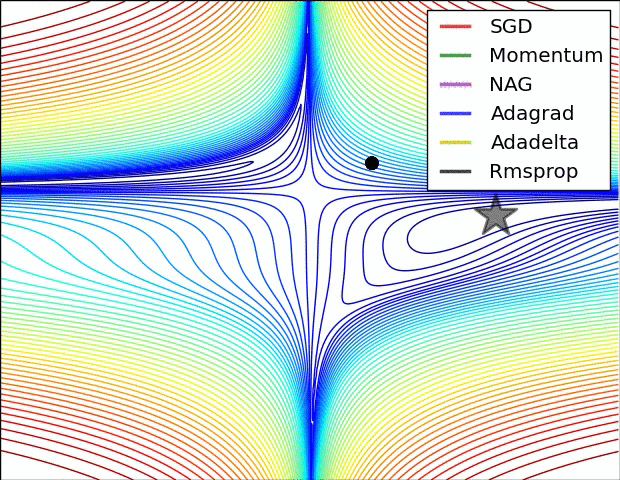

Let's see the effect of optimizer on the performance.

Val: sgd, Validation Score: 0.796, Test Score: 0.805
Val: adam, Validation Score: 0.807, Test Score: 0.810
Val: RMSprop, Validation Score: 0.809, Test Score: 0.813
Val: Adadelta, Validation Score: 0.782, Test Score: 0.795


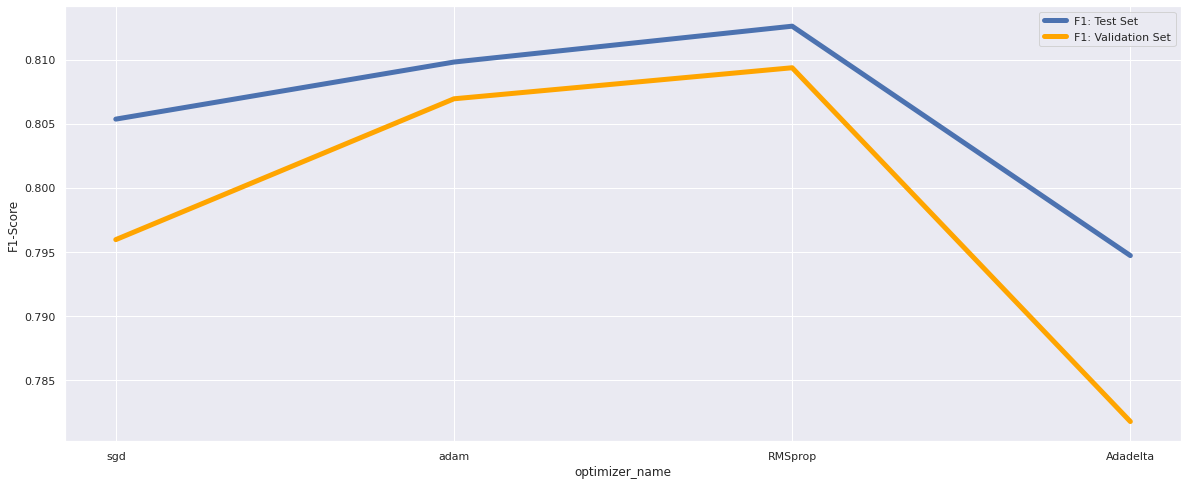

In [ ]:
model,best_optimizer = evaluate_efect_param(parameter_type='model_params',parameter_name='optimizer_name', values_list=['sgd','adam','RMSprop','Adadelta'])
kfold_params['model_params']['optimizer_name'] = best_optimizer

With their default configuration, ADAM and RMSprop are among the best available optimizers.

### Last Performance Check
The last model should be our best model so far. So let's see how the confusion matrix and performance looks like.

Weighted F1-score is 0.81


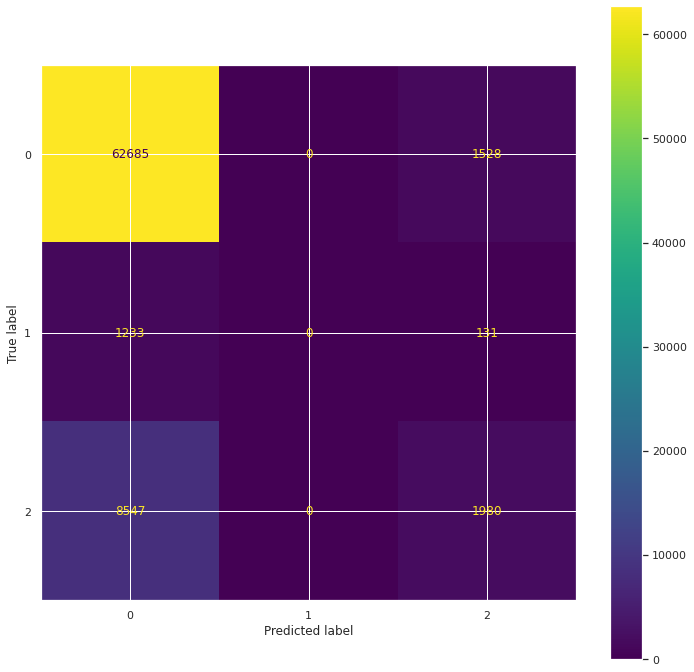

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
predictions = model.predict(X_test)
print('Weighted F1-score is %.2f' %f1_score(convert_predictions(y_test), convert_predictions(predictions), average='weighted'))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(convert_predictions(y_test), convert_predictions(predictions),ax=ax)
plt.show()

# Other Helpful Techniques


*   Ensemble learning: we can group several classifiers, with different architectures and parameters and combine their aggregated opinion on the class
*   Expanding dataset: in the next sessions on image analysis, we see how we can modify our training dataset to improve the performance and the robustness




Any Final Thoughts?

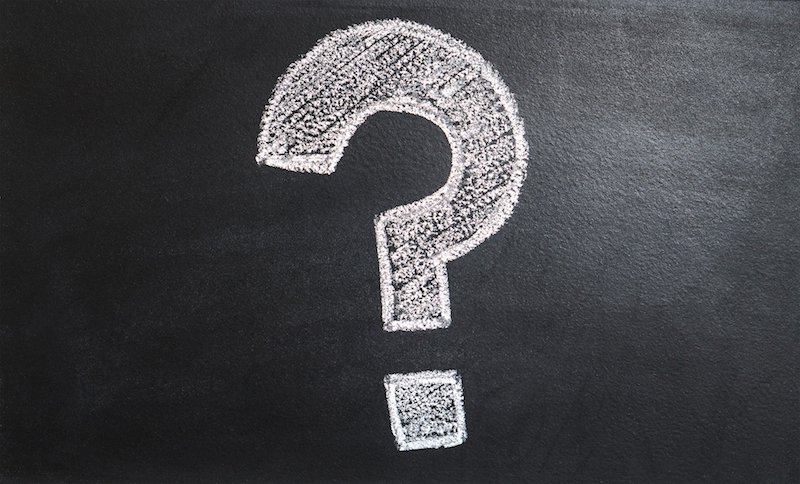

# Don't Forget the Survey!
Please help us improve the quality of the lab sessions by filling this [short suvery](https://forms.gle/ecxv7Ep1YH67bXpC7) about today's session.


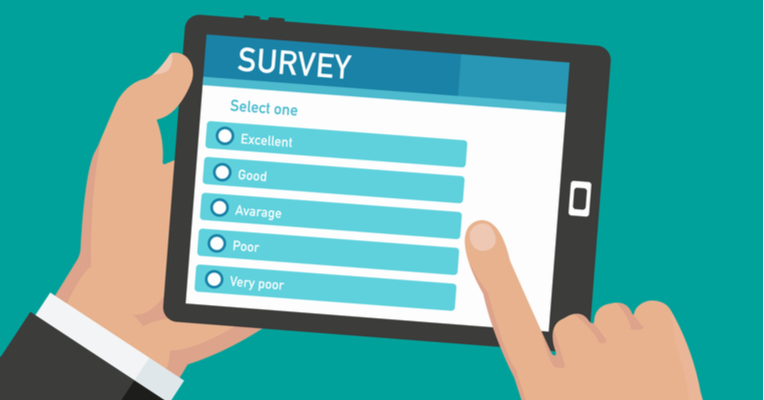